# P08 — Evaluation, Regularization & Bias–Variance  *(teaching the mind humility)*

> **The story so far.** In P07 the mind drew its first line and learned to say *yes* or *no*. It was
> proud — it could explain every example you had shown it, perfectly. And that is exactly the moment
> to worry. A child who can recite the answers to last night's homework hasn't learned arithmetic;
> they've memorised a page. The mind's first great temptation is the same: **memorise instead of
> understand.** This chapter teaches it humility — how to tell whether it has truly *learned*, and
> how to keep it from cheating.

Picture a doctor who is right 99% of the time on a disease that strikes 1 person in 100. Impressive —
until you notice they say "healthy" to *everyone* and are right about the 99 healthy people by
default. A model that fits its training data perfectly is often the *worst* one out in the world.
This notebook gives the mind the two skills that separate a practitioner from a beginner: **measuring
a classifier honestly** (beyond the flattering single number of accuracy) and **regularizing** it so
it generalises to people it has never met. Every metric is computed by hand on a tiny confusion
table, then verified with sklearn — story delivers the math, it never replaces it.

## B1 — Why accuracy lies: the confusion matrix

Back to that doctor. A model that *always* says "healthy" on a 1-in-100 disease is **99% accurate**
and **100% useless** — it never catches a single sick patient. Accuracy is a single number that
quietly averages two very different kinds of mistake into a flattering blur. To see what the mind is
*actually* doing, we stop trusting the average and count the four ways a yes/no call can land. That
tally is the **confusion matrix**:

```
                 predicted 0     predicted 1
actual 0        TN (true neg)   FP (false pos)
actual 1        FN (false neg)  TP (true pos)
```

**Worked example by hand.** 10 patients; truth and prediction:
```
truth = [1,1,1,1,0,0,0,0,0,0]   (4 sick, 6 healthy)
pred  = [1,1,0,0,1,0,0,0,0,0]   (model's guesses)
```
Tally:
```
TP = predicted 1 & actually 1  -> patients 1,2          = 2
FN = predicted 0 & actually 1  -> patients 3,4          = 2
FP = predicted 1 & actually 0  -> patient 5             = 1
TN = predicted 0 & actually 0  -> patients 6,7,8,9,10   = 5
```

In [1]:
import numpy as np
truth = np.array([1,1,1,1,0,0,0,0,0,0])
pred  = np.array([1,1,0,0,1,0,0,0,0,0])

TP = int(((pred==1)&(truth==1)).sum())
FN = int(((pred==0)&(truth==1)).sum())
FP = int(((pred==1)&(truth==0)).sum())
TN = int(((pred==0)&(truth==0)).sum())
print(f"TP={TP}  FN={FN}  FP={FP}  TN={TN}   (hand: 2,2,1,5)")
print("accuracy = (TP+TN)/total =", (TP+TN)/10, " (looks okay...)")

TP=2  FN=2  FP=1  TN=5   (hand: 2,2,1,5)
accuracy = (TP+TN)/total = 0.7  (looks okay...)


## B2 — Precision, recall, F1: what accuracy hides

A smoke alarm that shrieks at every slice of toast catches every real fire — but you stop believing
it. A smoke alarm so calm it only fires for an inferno never cries wolf — but it might let your
kitchen burn. Those are the two questions hiding inside the confusion matrix, and they have names.
From the four counts come the metrics that actually matter:
```
precision = TP / (TP + FP)   "when I say positive, how often am I right?"
recall    = TP / (TP + FN)   "of all real positives, how many did I catch?"
F1        = 2·precision·recall / (precision + recall)   (their harmonic mean)
```
There's a **tradeoff**: catching every sick patient (high recall) usually means more false alarms
(lower precision). Which matters more depends on the cost — a cancer screen prizes recall; a spam
filter prizes precision (don't trash real mail).

**Worked example by hand** (TP=2, FN=2, FP=1):
```
precision = 2/(2+1) = 0.667
recall    = 2/(2+2) = 0.500
F1        = 2·0.667·0.5/(0.667+0.5) = 0.667/1.167 = 0.571
```

In [2]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
truth = np.array([1,1,1,1,0,0,0,0,0,0]); pred = np.array([1,1,0,0,1,0,0,0,0,0])
TP,FN,FP = 2,2,1
prec = TP/(TP+FP); rec = TP/(TP+FN); f1 = 2*prec*rec/(prec+rec)
print("by hand : precision=%.3f recall=%.3f F1=%.3f" % (prec, rec, f1))
print("sklearn : precision=%.3f recall=%.3f F1=%.3f" %
      (precision_score(truth,pred), recall_score(truth,pred), f1_score(truth,pred)))
print("\nconfusion_matrix (rows=actual, cols=predicted):\n", confusion_matrix(truth,pred))

by hand : precision=0.667 recall=0.500 F1=0.571
sklearn : precision=0.667 recall=0.500 F1=0.571

confusion_matrix (rows=actual, cols=predicted):
 [[5 1]
 [2 2]]


## B3 — The ROC curve and AUC (threshold-free quality)

Turn the smoke alarm's sensitivity dial. Crank it up and it catches every fire but screams at toast;
turn it down and it stays quiet but misses real danger. There's no single "right" setting — it
depends on what you fear more. So instead of judging the mind at one dial position, we sweep the dial
through *every* setting and ask one deeper question: across all of them, does it tend to rank real
fires above false ones at all? That sweep is the ROC curve.

A classifier outputs a *probability*; turning it into 0/1 needs a **threshold** (default 0.5).
Different thresholds trade recall against false alarms. The **ROC curve** plots true-positive rate
vs false-positive rate across *all* thresholds, and **AUC** (area under it) summarises overall
ranking quality in one number: `0.5` = random guessing, `1.0` = perfect. AUC answers "how well does
the model *rank* positives above negatives, regardless of where I put the threshold?"

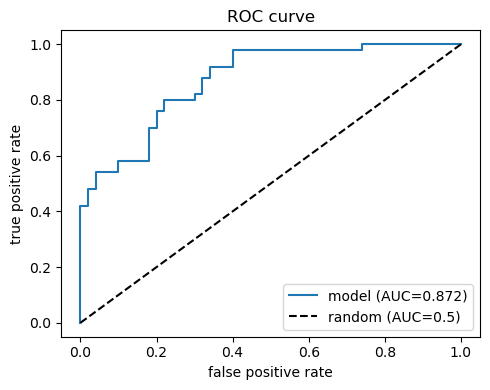

AUC = 0.872  -> better than random (0.5), worse than perfect (1.0)


In [3]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
rng = np.random.default_rng(0)
# scores: positives tend higher, but overlap
y     = np.array([0]*50 + [1]*50)
scores = np.concatenate([rng.normal(0.4,0.15,50), rng.normal(0.65,0.15,50)]).clip(0,1)

fpr, tpr, _ = roc_curve(y, scores)
auc = roc_auc_score(y, scores)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"model (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", label="random (AUC=0.5)")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC curve"); plt.legend(); plt.tight_layout(); plt.show()
print("AUC =", round(auc,3), " -> better than random (0.5), worse than perfect (1.0)")

## B4 — Regularization: shrink the weights to fight overfitting

Now we confront the temptation head-on. Give a student a formula sheet with room for three numbers
and they must find the real pattern; give them an infinite sheet and they'll just copy down every
answer they've seen. A model with big, wild weights is that infinite sheet — it has enough freedom to
bend itself around every noisy data point instead of learning the underlying shape. P05 named this
**overfitting**. The cure is to make the sheet smaller: **regularization** adds a penalty on weight
*size* to the loss, gently pressuring the mind to stay simple and actually understand:
```
L2 (Ridge):   loss + λ · Σ wᵢ²     -> shrinks all weights smoothly toward 0
L1 (Lasso):   loss + λ · Σ |wᵢ|    -> drives some weights exactly to 0 (feature selection)
```
`λ` (lambda) sets the strength. Bigger `λ` = simpler model. In deep learning L2 is called **weight
decay** (you'll set it on every optimizer in P12). We *show* it shrinking weights below.

In [4]:
import numpy as np
from sklearn.linear_model import Ridge
rng = np.random.default_rng(0)
# 15 features but only the first 3 truly matter -> easy to overfit
X = rng.normal(size=(40, 15))
true_w = np.array([3.0, -2.0, 1.0] + [0.0]*12)
y = X @ true_w + rng.normal(0, 0.5, size=40)

print(f"{'lambda':>8} {'||w||  (total weight size)':>28}")
for lam in [0.0, 1.0, 10.0, 100.0]:
    w = Ridge(alpha=lam, fit_intercept=False).fit(X, y).coef_
    print(f"{lam:>8} {np.linalg.norm(w):>20.3f}")
print("\nas lambda grows, total weight size shrinks -> a simpler, less overfit model.")

  lambda   ||w||  (total weight size)
     0.0                3.665
     1.0                3.538
    10.0                2.789
   100.0                1.046

as lambda grows, total weight size shrinks -> a simpler, less overfit model.


## B5 — The bias–variance tradeoff (the idea behind all of this)

Step back and you'll see one tension under everything in this chapter. Aim a bow at a target: shoot
too cautiously and every arrow lands in the same wrong spot (consistent, but off — too simple); shoot
too wildly and the arrows scatter all over (sensitive to every twitch — too complex). The mind faces
the same two failures, and they pull in opposite directions. Every model's test error decomposes into
these two opposing forces:
- **Bias** — error from being *too simple* to capture the pattern (underfitting). High bias = wrong
  in a consistent way.
- **Variance** — error from being *too sensitive* to the particular training data (overfitting).
  High variance = predictions swing wildly if you change the data slightly.

```
simple model:   high bias, low variance   (underfit)
complex model:  low bias,  high variance  (overfit)
sweet spot:     balanced -> lowest test error
```
Regularization, more data, and choosing the right model size are all just ways of **moving along
this tradeoff** toward the sweet spot. Keep this picture in mind for every model you ever build.

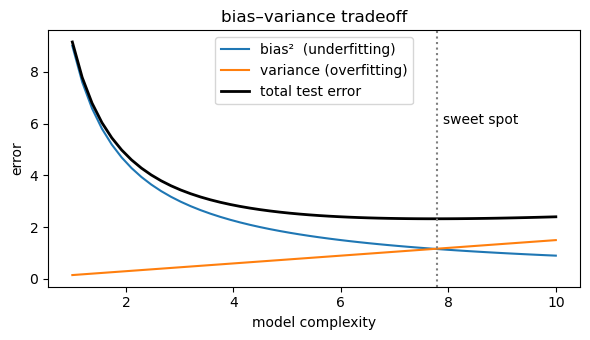

total error is lowest at complexity ≈ 7.8 — not the simplest, not the most complex.


In [5]:
import numpy as np, matplotlib.pyplot as plt
# cartoon of the tradeoff: error vs model complexity
complexity = np.linspace(1, 10, 50)
bias2    = 9 / complexity            # falls as model gets more complex
variance = 0.15 * complexity         # rises as model gets more complex
total    = bias2 + variance
plt.figure(figsize=(6,3.5))
plt.plot(complexity, bias2, label="bias²  (underfitting)")
plt.plot(complexity, variance, label="variance (overfitting)")
plt.plot(complexity, total, "k", lw=2, label="total test error")
best = complexity[np.argmin(total)]
plt.axvline(best, ls=":", c="gray"); plt.text(best+0.1, 6, "sweet spot")
plt.xlabel("model complexity"); plt.ylabel("error"); plt.legend(); plt.title("bias–variance tradeoff")
plt.tight_layout(); plt.show()
print(f"total error is lowest at complexity ≈ {best:.1f} — not the simplest, not the most complex.")

## Recap — judge honestly, regularize wisely

| Tool | Question it answers |
|------|---------------------|
| Confusion matrix | what *kinds* of mistakes (FP vs FN)? |
| Precision | when I predict positive, am I right? |
| Recall | do I catch the real positives? |
| F1 | balance of precision & recall |
| ROC / AUC | ranking quality across all thresholds |
| L2 / L1 penalty | shrink weights → less overfitting |
| Bias–variance | the framework behind all of the above |

## Common mistakes
1. **Reporting only accuracy**, especially on imbalanced data — it hides the failure mode.
2. **Ignoring which error is costly.** Tune the threshold for recall (medical) or precision (spam) deliberately.
3. **Picking the threshold on the test set.** Use validation; the test set is judged once.
4. **No regularization on a high-capacity model** → it memorises noise. Add weight decay by default.
5. **Thinking more data always beats regularization.** Both reduce variance; use whichever you can afford.

## Exercises (do them in new code cells)
1. For TP=8, FP=2, FN=4, TN=86: compute accuracy, precision, recall, F1 by hand. Which looks best/worst?
2. A spam filter must avoid trashing real email. Should you optimise precision or recall? Why?
3. In B4, add `Lasso` (L1) and print how many weights become exactly 0 as `λ` rises.
4. In B3, make the two score distributions overlap completely (same mean). What AUC do you expect, and what do you get?
5. On the bias–variance plot, where do "tiny model" and "giant unregularized model" sit, and which type of error dominates each?

---

**The mind has learned humility** — it can tell real understanding from memorisation, and we have the
tools to keep it honest. Before we hand it neurons, it deserves a starter kit of instincts. Next:
[P09 — Core Algorithms Tour](P09_Algorithms_Tour.ipynb) — a fast, hands-on pass through kNN, decision
trees, random forests, SVM, Naive Bayes, k-means and PCA, so the mind knows the whole classical
toolbox before we wire it a brain in Part 2.